[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/19_seaborn.ipynb)



# Seaborn : la visualisation statistique

Matplotlib trace tout, mais il faut souvent beaucoup de lignes pour un graphique
présentable. Seaborn est une couche par-dessus Matplotlib, pensée pour les
données statistiques : il connaît les DataFrames, colore par catégorie, et
produit des graphiques soignés en une ligne.

La règle générale : Seaborn pour explorer vite, Matplotlib pour peaufiner un
graphique final.

## Le plan

| Section | Le sujet |
|---|---|
| 1 | Le problème que Seaborn résout |
| 2 | `pairplot` : tout voir d'un coup |
| 3 | Préparer le Titanic |
| 4 | `catplot` et `boxplot` : variables catégorielles |
| 5 | `displot` : les distributions |
| 6 | `jointplot` : deux variables et leurs marges |
| 7 | `heatmap` : la matrice de corrélation |

## Trois pièges annoncés

`pairplot` sur un gros jeu de données est très lent il trace toutes les paires.

`corr()` échoue sur des colonnes textuelles : il faut `numeric_only=True`.

Et une corrélation ne capte que le lien linéaire deux variables liées en U
sortent à zéro.

Prérequis : Matplotlib, et des bases de Pandas.

## 1. Le problème que Seaborn résout

Chargeons le jeu iris, livré avec Seaborn pas de fichier à gérer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')
print(iris.shape)
iris.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


`load_dataset` télécharge un jeu d'exemple. C'est la bonne pratique pour un
notebook publié : aucun fichier local, donc reproductible partout.

Comparons un nuage de points en Matplotlib pur puis en Seaborn.

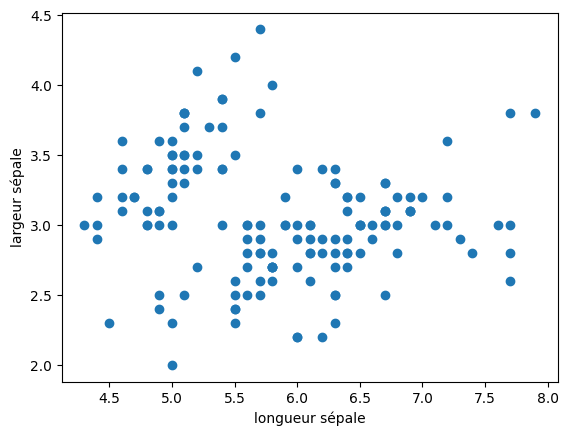

In [2]:
plt.scatter(iris['sepal_length'], iris['sepal_width'])
plt.xlabel('longueur sépale')
plt.ylabel('largeur sépale')
plt.show()

Ça marche, mais on ne distingue pas les espèces, et il a fallu nommer les axes à
la main. La version Seaborn fait mieux, en une ligne :

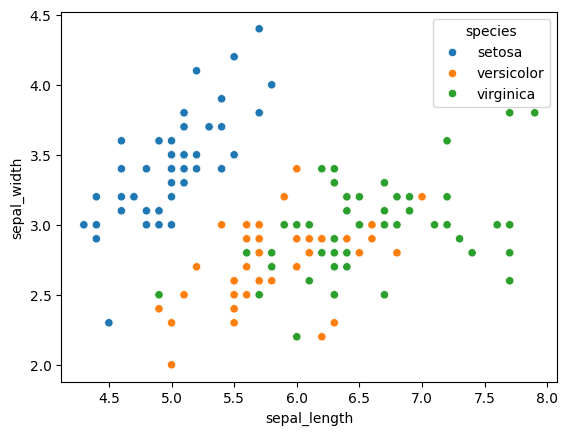

In [3]:
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')
plt.show()

Trois différences immédiates. Les points sont colorés par espèce grâce à
`hue`. Les axes sont nommés automatiquement d'après les colonnes. Et une légende apparaît toute seule.

C'est le principe de Seaborn : il connaît le DataFrame, donc il déduit les
étiquettes et gère les catégories.

Note de syntaxe importante. Seaborn récent exige `x=` et `y=` nommés. Les
passer en position `sns.scatterplot(iris, 'sepal_length', ...)` provoque une
erreur. C'est un changement récent qui casse beaucoup de vieux exemples.

## 2. pairplot : tout voir d'un coup

`pairplot` trace chaque variable contre chaque autre. C'est l'outil
d'exploration le plus rentable.

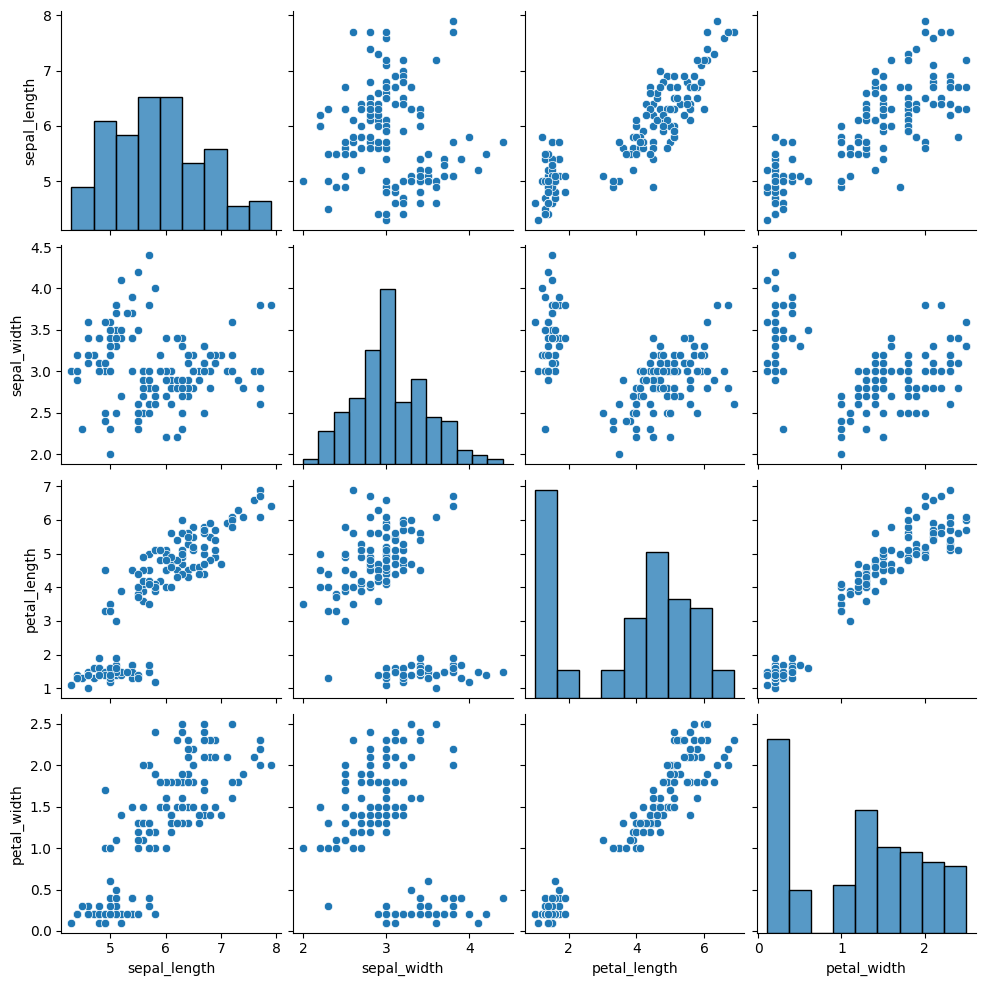

In [4]:
sns.pairplot(iris)
plt.show()

Sur la diagonale, la distribution de chaque variable seule. Ailleurs, le
nuage de points de chaque paire.

Avec `hue`, chaque espèce reçoit une couleur, ce qui révèle instantanément
lesquelles se séparent.

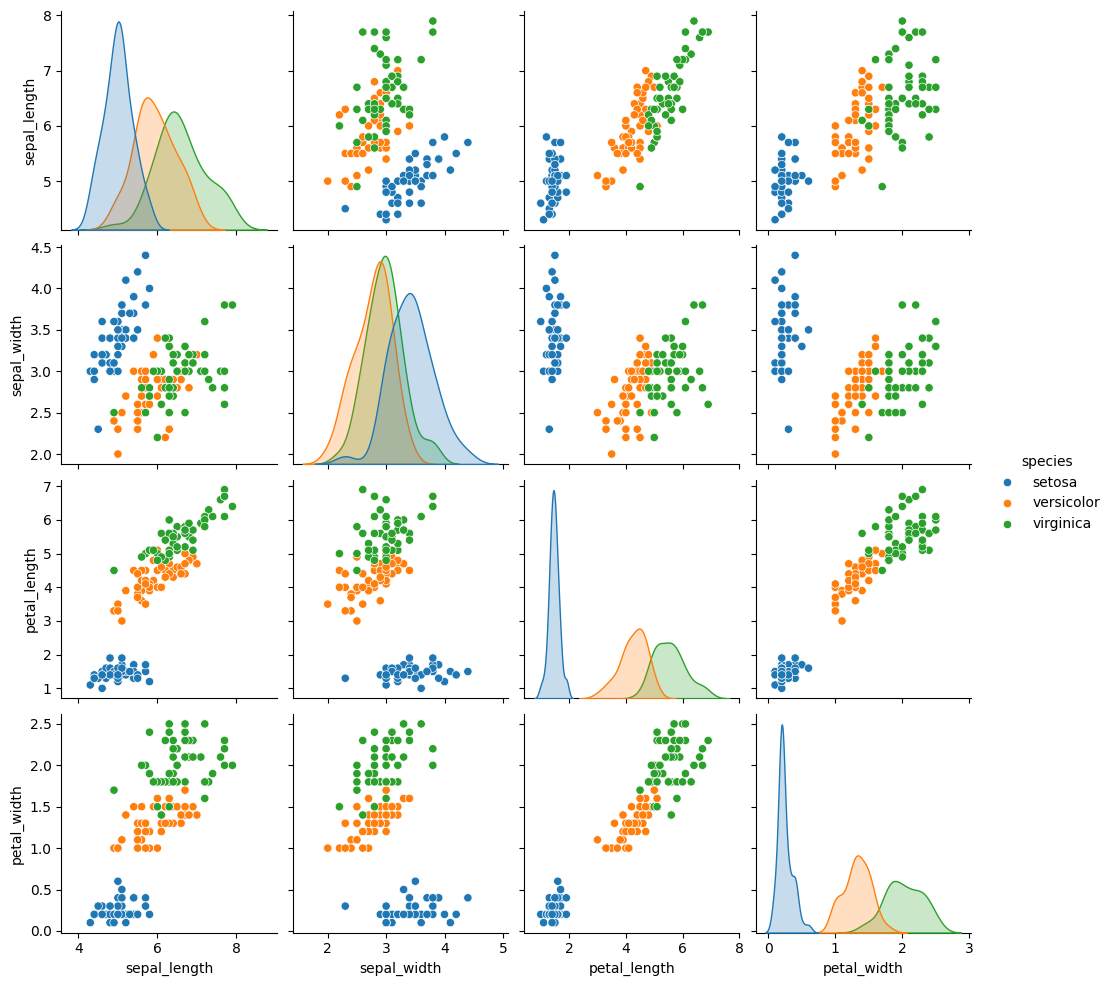

In [5]:
sns.pairplot(iris, hue='species')
plt.show()

La lecture est frappante : sur les cases faisant intervenir `petal_length` ou
`petal_width`, les trois espèces forment des groupes nets. Sur les sépales, elles
se chevauchent.

La conclusion pour le machine learning saute aux yeux : les pétales
distinguent mieux les espèces que les sépales. C'est le genre d'intuition qu'on
obtient en dix secondes avec `pairplot`, et qui guiderait le choix des variables
d'un modèle.

### Le piège : la lenteur

`pairplot` trace toutes les paires. Pour p variables, cela fait p² graphiques.

Sur iris 4 variables, 150 lignes c'est instantané. Sur un jeu de 30 variables
et 100 000 lignes, ce serait 900 graphiques de 100 000 points chacun : plusieurs
minutes, voire un plantage.

La parade est de se restreindre à quelques variables :

```python
sns.pairplot(donnees, vars=['age', 'revenu', 'score'], hue='classe')
```

Ou d'échantillonner les lignes :

```python
sns.pairplot(donnees.sample(1000), hue='classe')
```

## 3. Préparer le Titanic

Seaborn fournit aussi le Titanic, dans une version enrichie.

In [6]:
titanic = sns.load_dataset('titanic')
print(titanic.shape)
titanic.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Cette version a plus de colonnes que le fichier brut, dont certaines redondantes : `alive` répète `survived`, `class` répète `pclass`,
`embark_town` répète `embarked`.

On les retire, et on supprime les lignes incomplètes pour simplifier.

In [7]:
titanic = titanic.drop(columns=['alone', 'alive', 'adult_male', 'who',
                                'embark_town', 'class', 'deck'])
titanic = titanic.dropna(axis=0)

print('forme après nettoyage :', titanic.shape)
titanic.head()

forme après nettoyage : (712, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Deux réserves, déjà rencontrées au notebook Pandas.

`drop` avec `columns=` est plus clair que `drop(..., axis=1)` : on voit qu'on
retire des colonnes.

Mais `dropna` mérite prudence. Sur le Titanic, les âges manquants ne manquent pas
au hasard les supprimer biaise le taux de survie. Ici on accepte cette perte
pour aller vite, mais sur une vraie analyse il faudrait imputer plutôt que
supprimer.

Vérifions l'ampleur de la perte :

In [8]:
titanic_complet = sns.load_dataset('titanic')
print('avant dropna :', len(titanic_complet), 'passagers')
print('après dropna :', len(titanic), 'passagers')
print('perdus :', len(titanic_complet) - len(titanic))

avant dropna : 891 passagers
après dropna : 712 passagers
perdus : 179


On perd une part notable des passagers, essentiellement à cause des âges et de la
cabine manquants. À garder en tête pour l'interprétation.

## 4. catplot et boxplot : les variables catégorielles

`catplot` croise une variable catégorielle et une variable numérique.

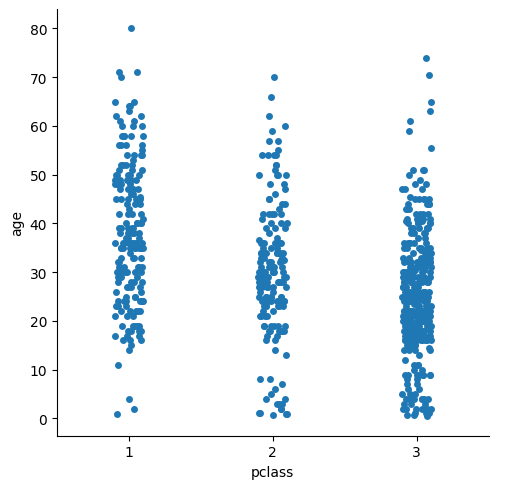

In [9]:
sns.catplot(data=titanic, x='pclass', y='age')
plt.show()

Chaque classe forme une colonne de points. On voit déjà que la première classe
est plus âgée en moyenne logique, il fallait des moyens.

Avec `hue`, on ajoute une troisième dimension :

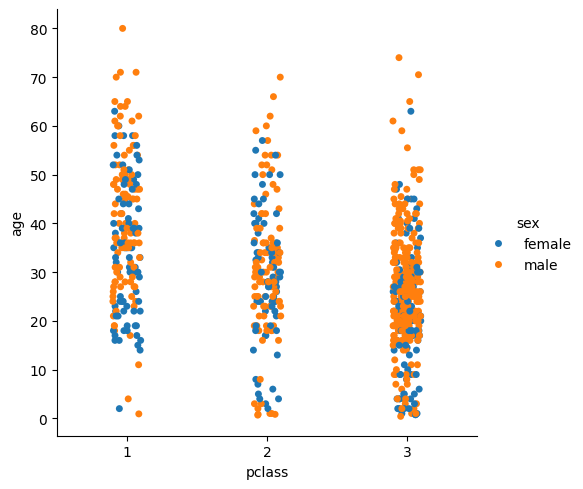

In [10]:
sns.catplot(data=titanic, x='pclass', y='age', hue='sex')
plt.show()

### boxplot : résumer une distribution

Le nuage de points devient illisible quand il y a beaucoup de monde. La boîte à
moustaches résume chaque groupe.

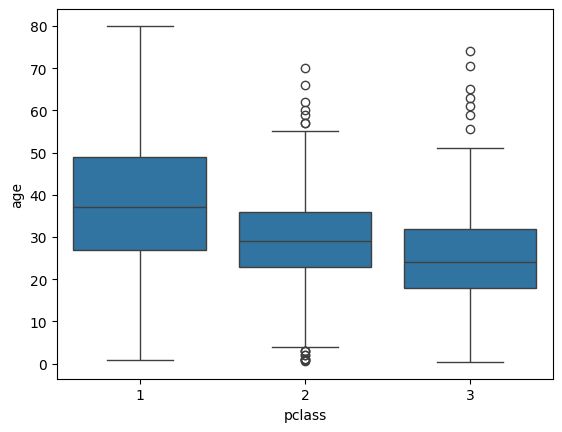

In [11]:
sns.boxplot(data=titanic, x='pclass', y='age')
plt.show()

Comment lire une boîte :

- la ligne centrale est la médiane,
- la boîte couvre les 50 % du milieu (du 1er au 3e quartile),
- les moustaches vont jusqu'aux valeurs extrêmes raisonnables,
- les points isolés au-delà sont les valeurs aberrantes.

C'est bien plus dense qu'un nuage : d'un coup d'œil, on compare les médianes et
les dispersions des trois classes.

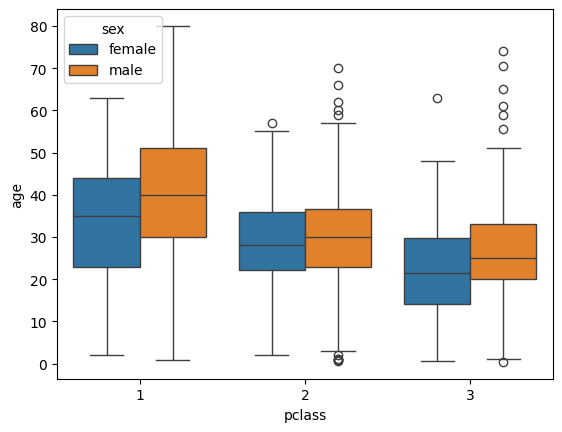

In [12]:
sns.boxplot(data=titanic, x='pclass', y='age', hue='sex')
plt.show()

La médiane d'âge baisse de la première à la troisième classe, dans les deux
sexes. Le boxplot révèle cette structure sans qu'on calcule quoi que ce soit.

Une variante, le `violinplot`, ajoute la forme de la distribution :

```python
sns.violinplot(data=titanic, x='pclass', y='age', hue='sex', split=True)
```

<Axes: xlabel='pclass', ylabel='age'>

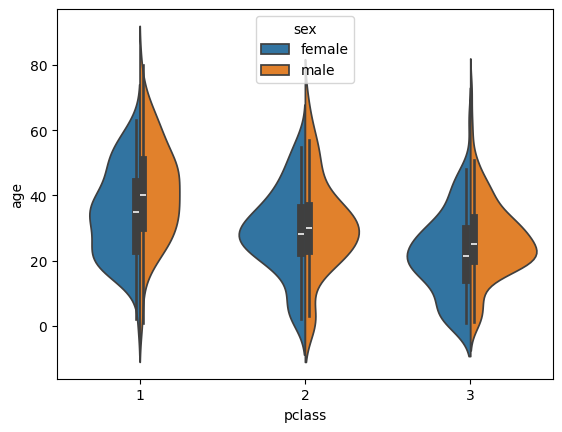

In [12]:
sns.violinplot(data=titanic, x='pclass', y='age', hue='sex', split=True)

## 5. displot : les distributions

`displot` trace la distribution d'une variable comment ses valeurs se
répartissent.

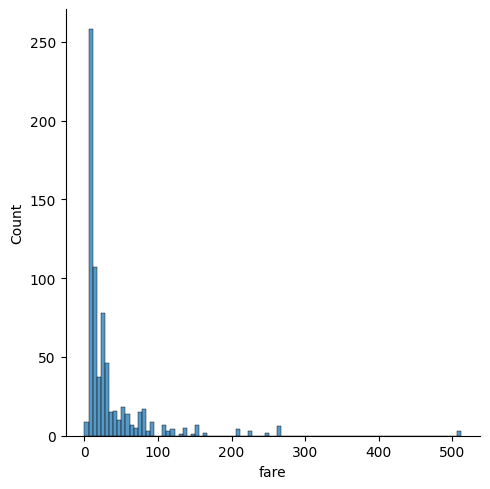

In [13]:
sns.displot(titanic['fare'])
plt.show()

La distribution du prix du billet est très asymétrique : une majorité de
billets bon marché, et une longue traîne de tarifs élevés.

C'est un cas typique où la moyenne trompe : quelques billets de luxe la
tirent vers le haut, alors que la médiane décrit mieux le passager ordinaire.
C'est la leçon du notebook 08.

In [14]:
print(f'moyenne : {titanic["fare"].mean():.2f}')
print(f'médiane : {titanic["fare"].median():.2f}')

moyenne : 34.57
médiane : 15.65


La moyenne est bien supérieure à la médiane, ce qui confirme l'asymétrie.

`displot` accepte plusieurs représentations :

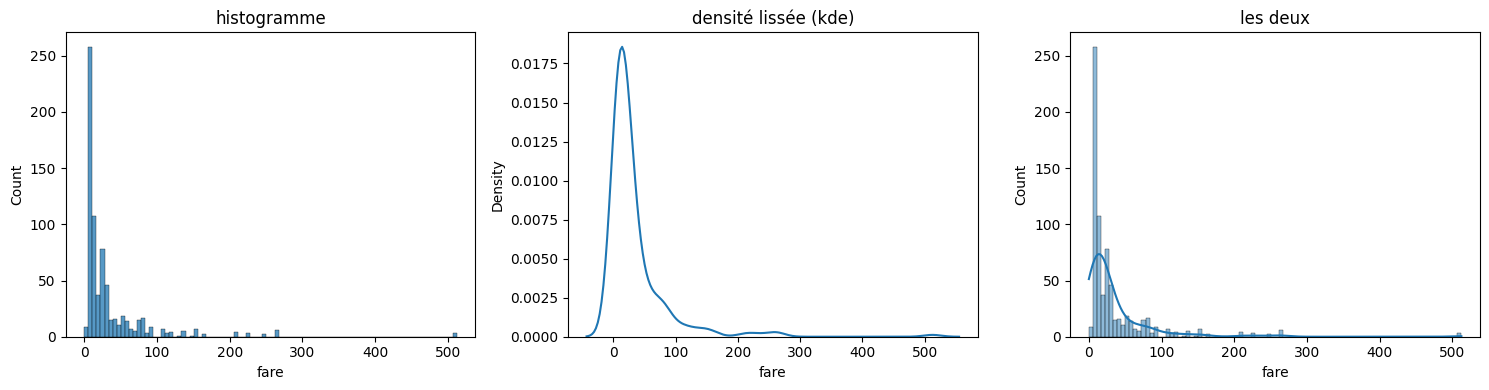

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(titanic['fare'], ax=ax[0]); ax[0].set_title('histogramme')
sns.kdeplot(titanic['fare'], ax=ax[1]); ax[1].set_title('densité lissée (kde)')
sns.histplot(titanic['fare'], kde=True, ax=ax[2]); ax[2].set_title('les deux')

plt.tight_layout()
plt.show()

L'histogramme compte les effectifs par tranche. Le `kde` (*kernel density
estimate*) en donne une version lissée. Combinés, ils se complètent.

On peut comparer deux groupes sur la même figure :

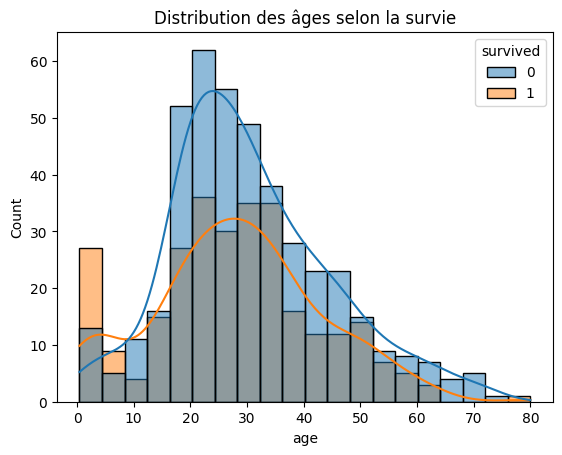

In [17]:
sns.histplot(data=titanic, x='age', hue='survived', kde=True)
plt.title('Distribution des âges selon la survie')
plt.show()

On distingue les enfants, qui survivent proportionnellement mieux la structure
qu'on avait trouvée à la main dans les exercices du notebook Pandas.

## 6. jointplot : deux variables et leurs marges

`jointplot` combine un nuage central et les distributions de chaque variable sur
les côtés.

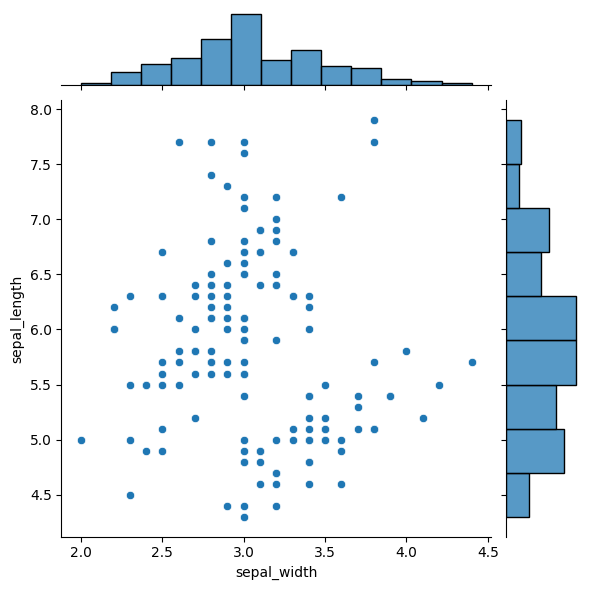

In [18]:
sns.jointplot(data=iris, x='sepal_width', y='sepal_length')
plt.show()

Au centre, la relation entre les deux variables. Sur les bords, comment chacune
se répartit seule. C'est deux graphiques en un.

Rappel de syntaxe : `x=` et `y=` nommés, sinon erreur c'est le piège de la
section 1.

L'argument `kind` change la représentation centrale :

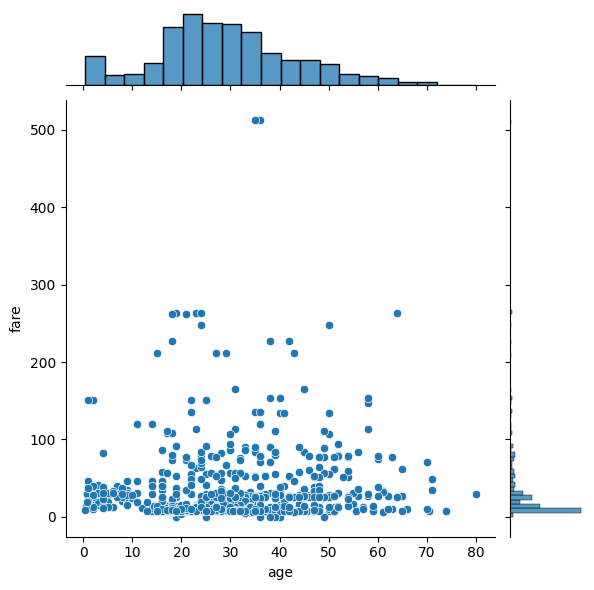

In [19]:
sns.jointplot(data=titanic, x='age', y='fare')
plt.show()

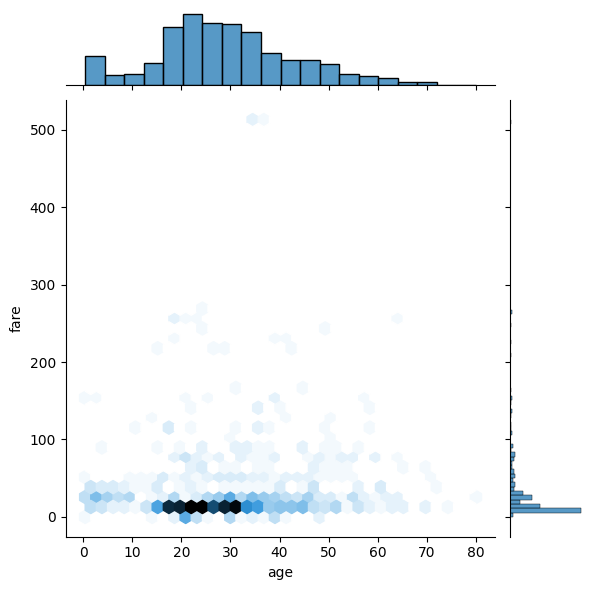

In [20]:
sns.jointplot(data=titanic, x='age', y='fare', kind='hex')
plt.show()

`kind='hex'` regroupe les points en cellules hexagonales colorées par densité.
C'est la bonne réponse au problème du surtracé : quand des milliers de points
se superposent, un nuage classique devient une tache noire illisible. Le hexbin
montre où ils se concentrent.

`kind='kde'` donne des courbes de niveau, `kind='reg'` ajoute une droite de
régression.

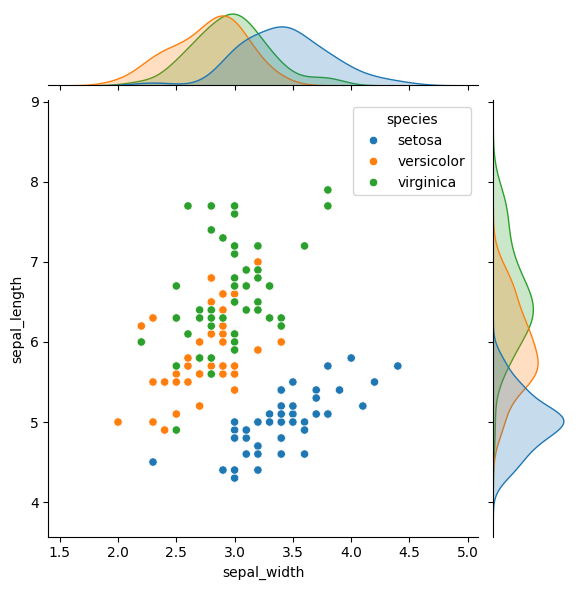

In [23]:
sns.jointplot(data=iris, x='sepal_width', y='sepal_length', hue='species')
plt.show()

Avec `hue`, on retrouve la séparation des espèces, cette fois avec leurs
distributions marginales chaque espèce a sa propre courbe sur les bords.

## 7. heatmap : la matrice de corrélation

La heatmap colore une matrice de nombres. Son usage le plus courant : visualiser
les corrélations.

In [24]:
try:
    titanic.corr()
except ValueError as e:
    print('ValueError :', str(e)[:70])

ValueError : could not convert string to float: 'male'


### Le piège : corr échoue sur du texte

`corr()` ne sait pas corréler `'male'` et `'female'`. Deux solutions.

La première, ignorer les colonnes textuelles :

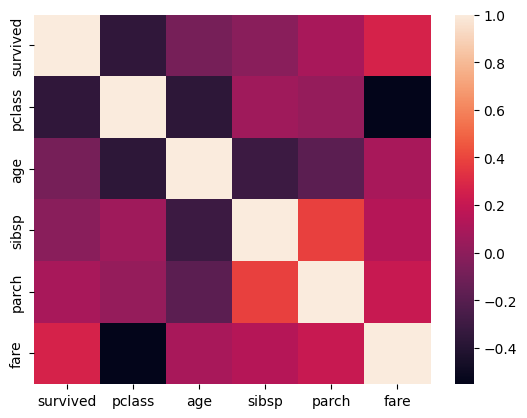

In [25]:
sns.heatmap(titanic.corr(numeric_only=True))
plt.show()

`numeric_only=True` écarte `sex` et `embarked`. Mais c'est dommage : le sexe est
la variable la plus liée à la survie. Mieux vaut le convertir en nombre, comme au
notebook Pandas.

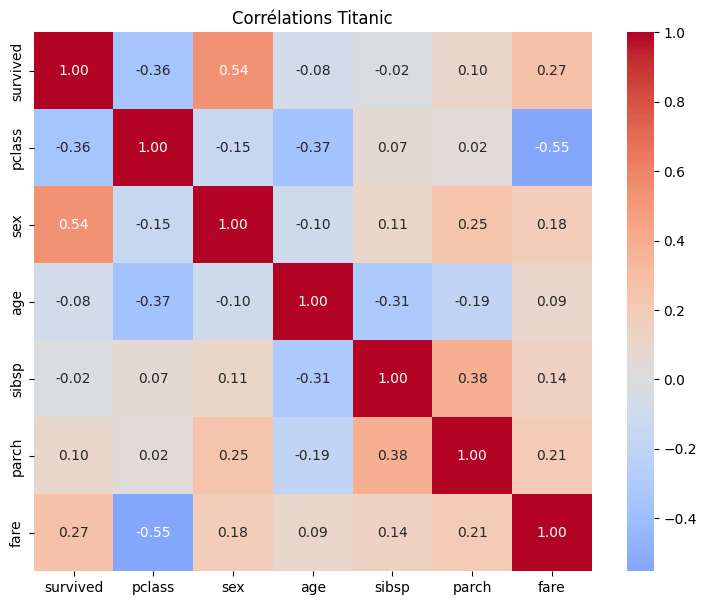

In [26]:
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

correlation = titanic.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Corrélations Titanic')
plt.show()

Trois arguments rendent la heatmap lisible :

- `annot=True` écrit la valeur dans chaque case, sinon on ne lit que des couleurs,
- `cmap='coolwarm'` met le négatif en bleu et le positif en rouge,
- `center=0` place le blanc à zéro, pour séparer d'un coup d'œil les deux signes.

La lecture. La ligne `survived` est la plus intéressante. `sex` y montre une
forte corrélation positive être une femme (codée 1) augmente nettement la
survie. `pclass` est négative : plus le numéro de classe est élevé (donc plus
modeste), moins on survit.

### Le piège d'interprétation

Une corrélation ne mesure que le lien linéaire. Une corrélation proche de zéro
ne signifie pas « aucun lien » seulement « aucun lien en ligne droite ».

In [27]:
x = np.linspace(-3, 3, 200)
y = x**2 # lien parfait, mais en U

print('Corrélation de x et x² :', np.corrcoef(x, y)[0, 1].round(4))

Corrélation de x et x² : -0.0


`x` et `x²` sont pourtant parfaitement liés connaître `x` donne exactement `y`.
Mais la corrélation est quasi nulle, parce que la relation est symétrique, pas
linéaire.

La leçon : une corrélation faible n'autorise pas à conclure « pas de relation ».
Il faut regarder le nuage de points d'où l'utilité du `pairplot` de la section
2, qui montre la forme réelle des relations.

## 8. Mémo

### Les graphiques

| Fonction | Usage |
|---|---|
| `scatterplot` | nuage, avec `hue` pour colorer |
| `pairplot` | toutes les paires, exploration |
| `catplot` | catégorie contre numérique, en points |
| `boxplot` | résumé par boîte à moustaches |
| `violinplot` | boîte + forme de distribution |
| `displot` / `histplot` | distribution d'une variable |
| `kdeplot` | densité lissée |
| `jointplot` | deux variables + marges |
| `heatmap` | matrice colorée |

### Arguments récurrents

| Argument | Effet |
|---|---|
| `data=` | le DataFrame |
| `x=`, `y=` | les colonnes (nommées obligatoirement) |
| `hue=` | colore par une catégorie |
| `kind=` | type de tracé (hex, kde, reg) |
| `annot=True` | écrit les valeurs (heatmap) |

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `x`, `y` en position | erreur, il faut les nommer |
| `pairplot` sur gros jeu | très lent, p² graphiques |
| `corr()` sur du texte | `ValueError`, utiliser `numeric_only=True` |
| Corrélation ≈ 0 | pas de lien **linéaire**, mais peut-être un autre |
| `dropna` sur Titanic | biaise, les âges ne manquent pas au hasard |
| Nuage surchargé | utiliser `kind='hex'` |

## 9. Exercices

**Exercice 1**

Sur le jeu iris, produis un `pairplot` coloré par espèce, puis identifie
visuellement les deux variables qui séparent le mieux les trois espèces.
Confirme ton intuition avec un `boxplot` de ces variables par espèce.

**Exercice 2**

Sur le Titanic, construis une figure à quatre sous-graphiques Seaborn qui
racontent l'histoire de la survie : par sexe, par classe, par âge, et la heatmap
de corrélation. Commente ce que chacun révèle.

**Exercice 3**

Ce code veut montrer que le prix du billet n'a pas d'effet sur la survie, en
s'appuyant sur une corrélation faible :

```python
correlation = titanic['fare'].corr(titanic['survived'])
print(f'Corrélation fare/survived : {correlation:.3f}')
```

La corrélation est effectivement modeste. Pourtant la conclusion est fausse.
Montre-le avec un `boxplot` du prix selon la survie, puis explique pourquoi la
corrélation sous-estime le lien, et propose une meilleure façon de le mesurer.

## Pour continuer

C'est la fin du bloc visualisation. Tu peux maintenant explorer un jeu de données
avant même de le modéliser c'est l'étape d'analyse exploratoire, qu'on
retrouvera au notebook 27.

Le notebook suivant ouvre scikit-learn, le cœur du machine learning. Toute la
préparation vue jusqu'ici NumPy, Pandas, visualisation sert à amener les
données dans la forme qu'un modèle attend.

In [28]:
# Exercice 1

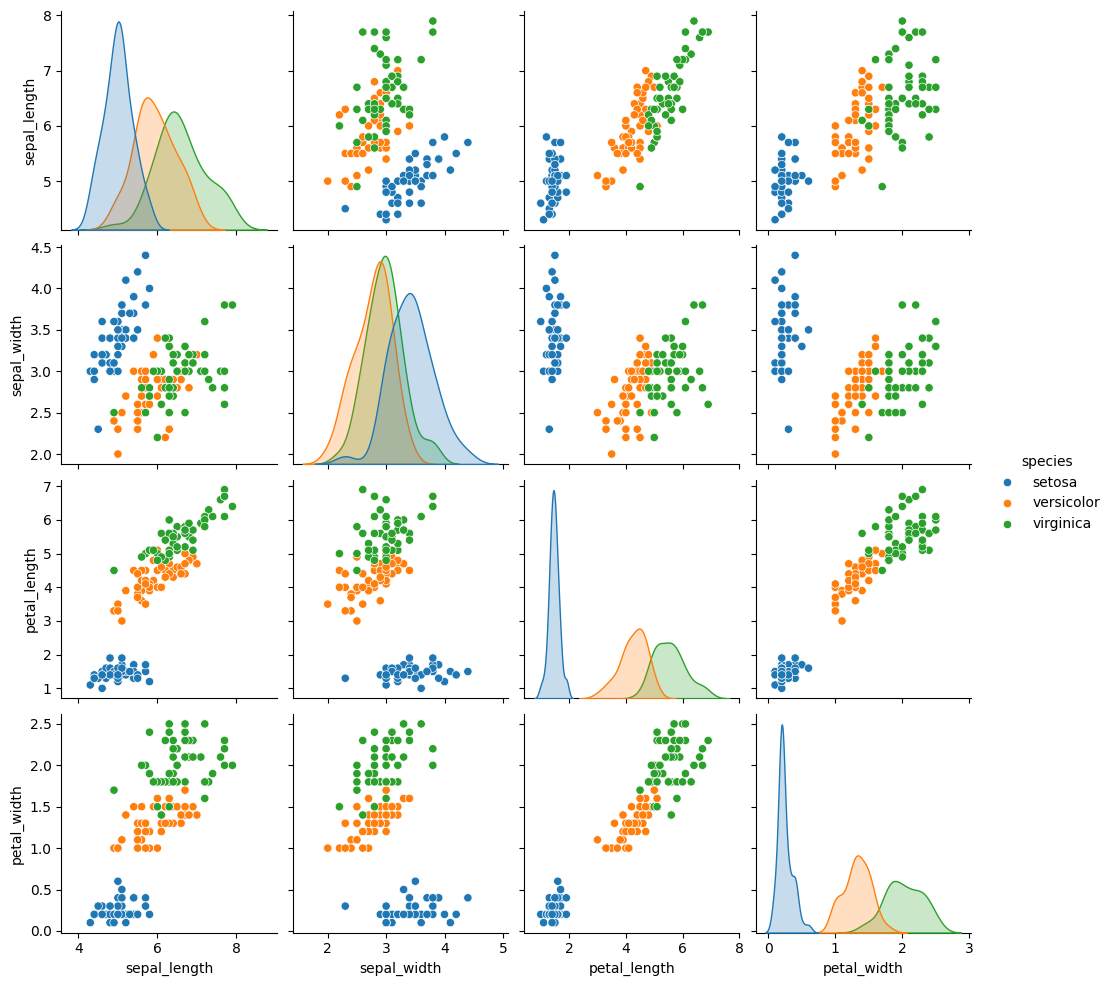

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset('iris')

sns.pairplot(iris, hue='species')
plt.show()

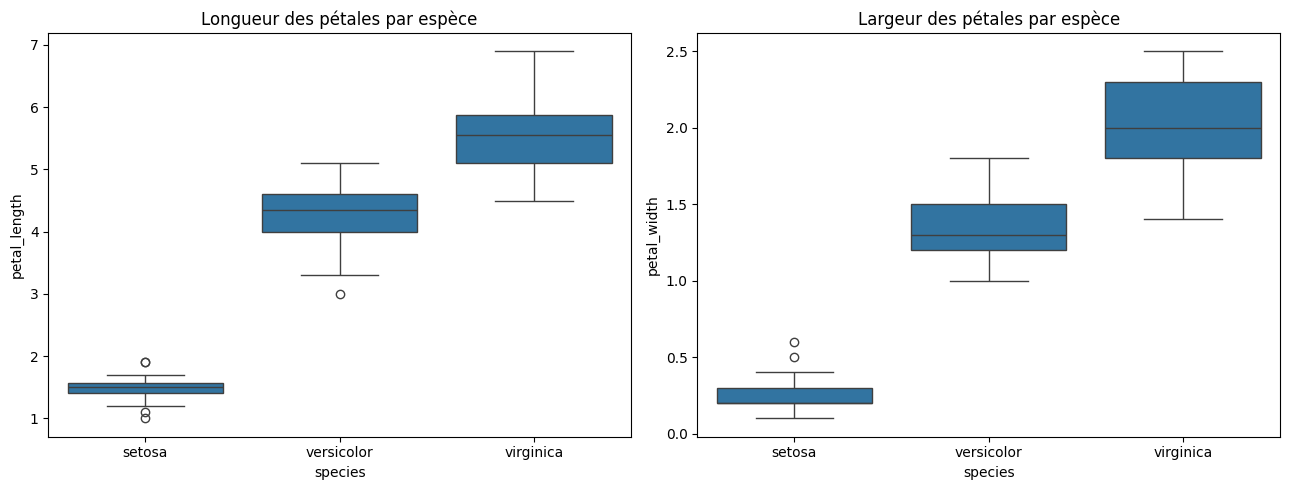

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=iris, x='species', y='petal_length', ax=ax[0])
ax[0].set_title('Longueur des pétales par espèce')

sns.boxplot(data=iris, x='species', y='petal_width', ax=ax[1])
ax[1].set_title('Largeur des pétales par espèce')

plt.tight_layout()
plt.show()

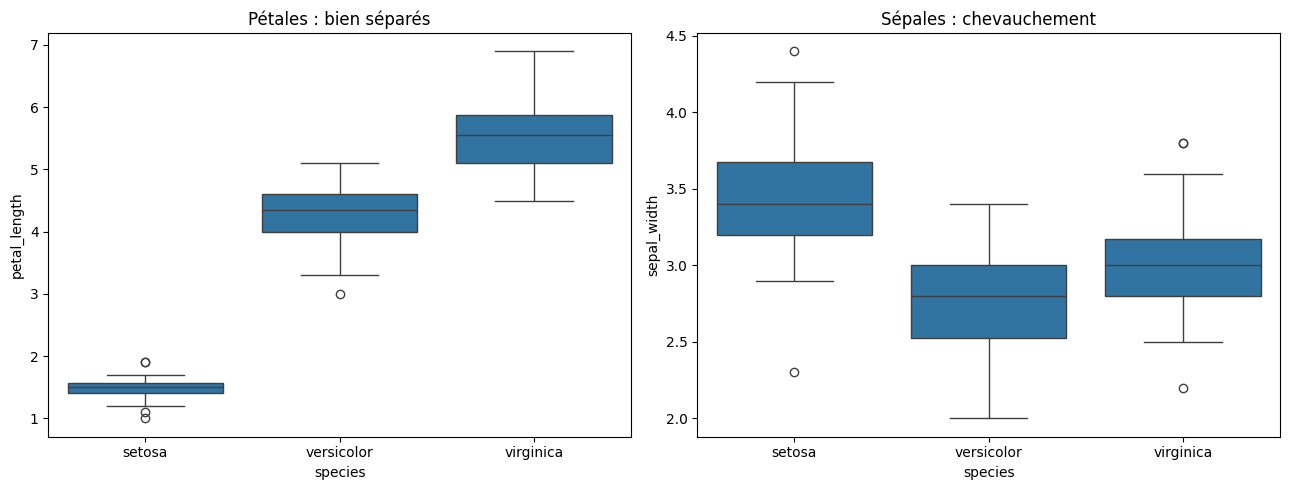

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=iris, x='species', y='petal_length', ax=ax[0])
ax[0].set_title('Pétales : bien séparés')

sns.boxplot(data=iris, x='species', y='sepal_width', ax=ax[1])
ax[1].set_title('Sépales : chevauchement')

plt.tight_layout()
plt.show()

In [33]:
for variable in ['petal_length', 'sepal_width']:
    setosa = iris[iris['species'] == 'setosa'][variable]
    autres = iris[iris['species'] != 'setosa'][variable]
    print(f'{variable:<14} setosa max = {setosa.max():.1f}, '
          f'autres min = {autres.min():.1f}')

petal_length   setosa max = 1.9, autres min = 3.0
sepal_width    setosa max = 4.4, autres min = 2.0


In [34]:
# Exericice 2

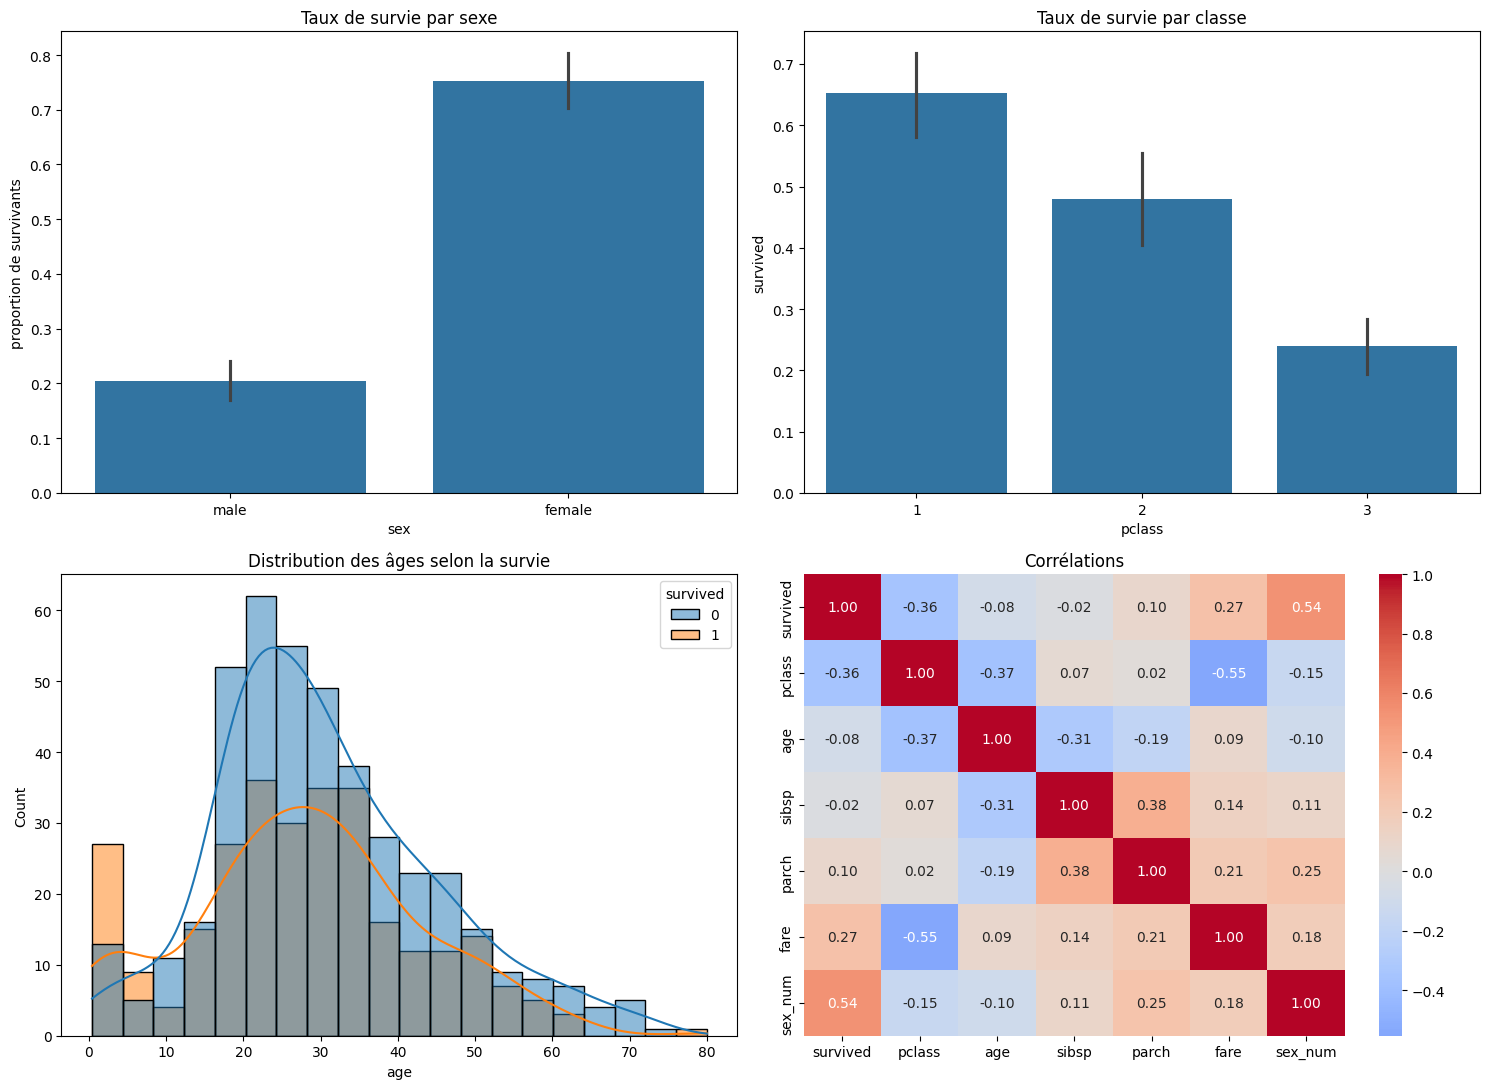

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset('titanic')
titanic = titanic.drop(columns=['alone', 'alive', 'adult_male', 'who',
                                'embark_town', 'class', 'deck'])
titanic = titanic.dropna()
titanic['sex_num'] = titanic['sex'].map({'male': 0, 'female': 1})

fig, ax = plt.subplots(2, 2, figsize=(15, 11))

# 1. Survie par sexe
sns.barplot(data=titanic, x='sex', y='survived', ax=ax[0, 0])
ax[0, 0].set_title('Taux de survie par sexe')
ax[0, 0].set_ylabel('proportion de survivants')

# 2. Survie par classe
sns.barplot(data=titanic, x='pclass', y='survived', ax=ax[0, 1])
ax[0, 1].set_title('Taux de survie par classe')

# 3. Distribution des âges selon la survie
sns.histplot(data=titanic, x='age', hue='survived', kde=True, ax=ax[1, 0])
ax[1, 0].set_title('Distribution des âges selon la survie')

# 4. Heatmap de corrélation
correlation = titanic.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax[1, 1])
ax[1, 1].set_title('Corrélations')

plt.tight_layout()
plt.show()

In [36]:
# Exercice 3

In [37]:
correlation = titanic['fare'].corr(titanic['survived'])
print(f'Corrélation fare/survived : {correlation:.3f}')

Corrélation fare/survived : 0.266


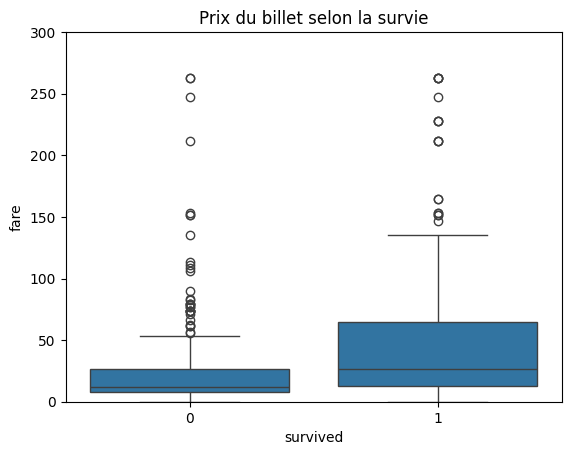

In [38]:
sns.boxplot(data=titanic, x='survived', y='fare')
plt.title('Prix du billet selon la survie')
plt.ylim(0, 300) # on coupe les valeurs extrêmes pour la lisibilité
plt.show()

In [39]:
print(titanic.groupby('survived')['fare'].agg(['median', 'mean']).round(2))

          median   mean
survived               
0          11.89  22.97
1          26.25  51.65


In [40]:
survivants = titanic[titanic['survived'] == 1]['fare']
morts = titanic[titanic['survived'] == 0]['fare']

print(f'Prix médian, survivants : {survivants.median():.2f}')
print(f'Prix médian, morts : {morts.median():.2f}')
print(f'Rapport : {survivants.median() / morts.median():.1f}x')

Prix médian, survivants : 26.25
Prix médian, morts : 11.89
Rapport : 2.2x


In [42]:
import numpy as np

titanic['log_fare'] = np.log1p(titanic['fare']) # log(1 + fare)
correlation_log = titanic['log_fare'].corr(titanic['survived'])

print(f'Corrélation brute : {titanic["fare"].corr(titanic["survived"]):.3f}')
print(f'Corrélation après log  : {correlation_log:.3f}')

Corrélation brute : 0.266
Corrélation après log  : 0.338
